Dataset size: 426 images

Age statistics:
count    426.000000
mean       6.056338
std        5.908448
min        1.000000
25%        2.000000
50%        4.000000
75%        9.000000
max       46.000000
Name: age, dtype: float64

Sample rows:
                image  age
0  a1987-05029c_1.jpg    9
1  a1987-05029c_2.jpg    9
2  a1987-05029c_3.jpg    9
3     a20075259_1.jpg    3
4     a20075259_2.jpg    3

ANALYZING IMAGE DIMENSIONS

=== Image Dimension Analysis (n=50) ===
Height - Mean: 197.3, Std: 19.0, Range: [64, 200]
Width  - Mean: 309.0, Std: 170.0, Range: [84, 924]
Suggested padding width: 924

VISUALIZING ORIGINAL vs CLAHE

Comparison saved to 'clahe_comparison.png'


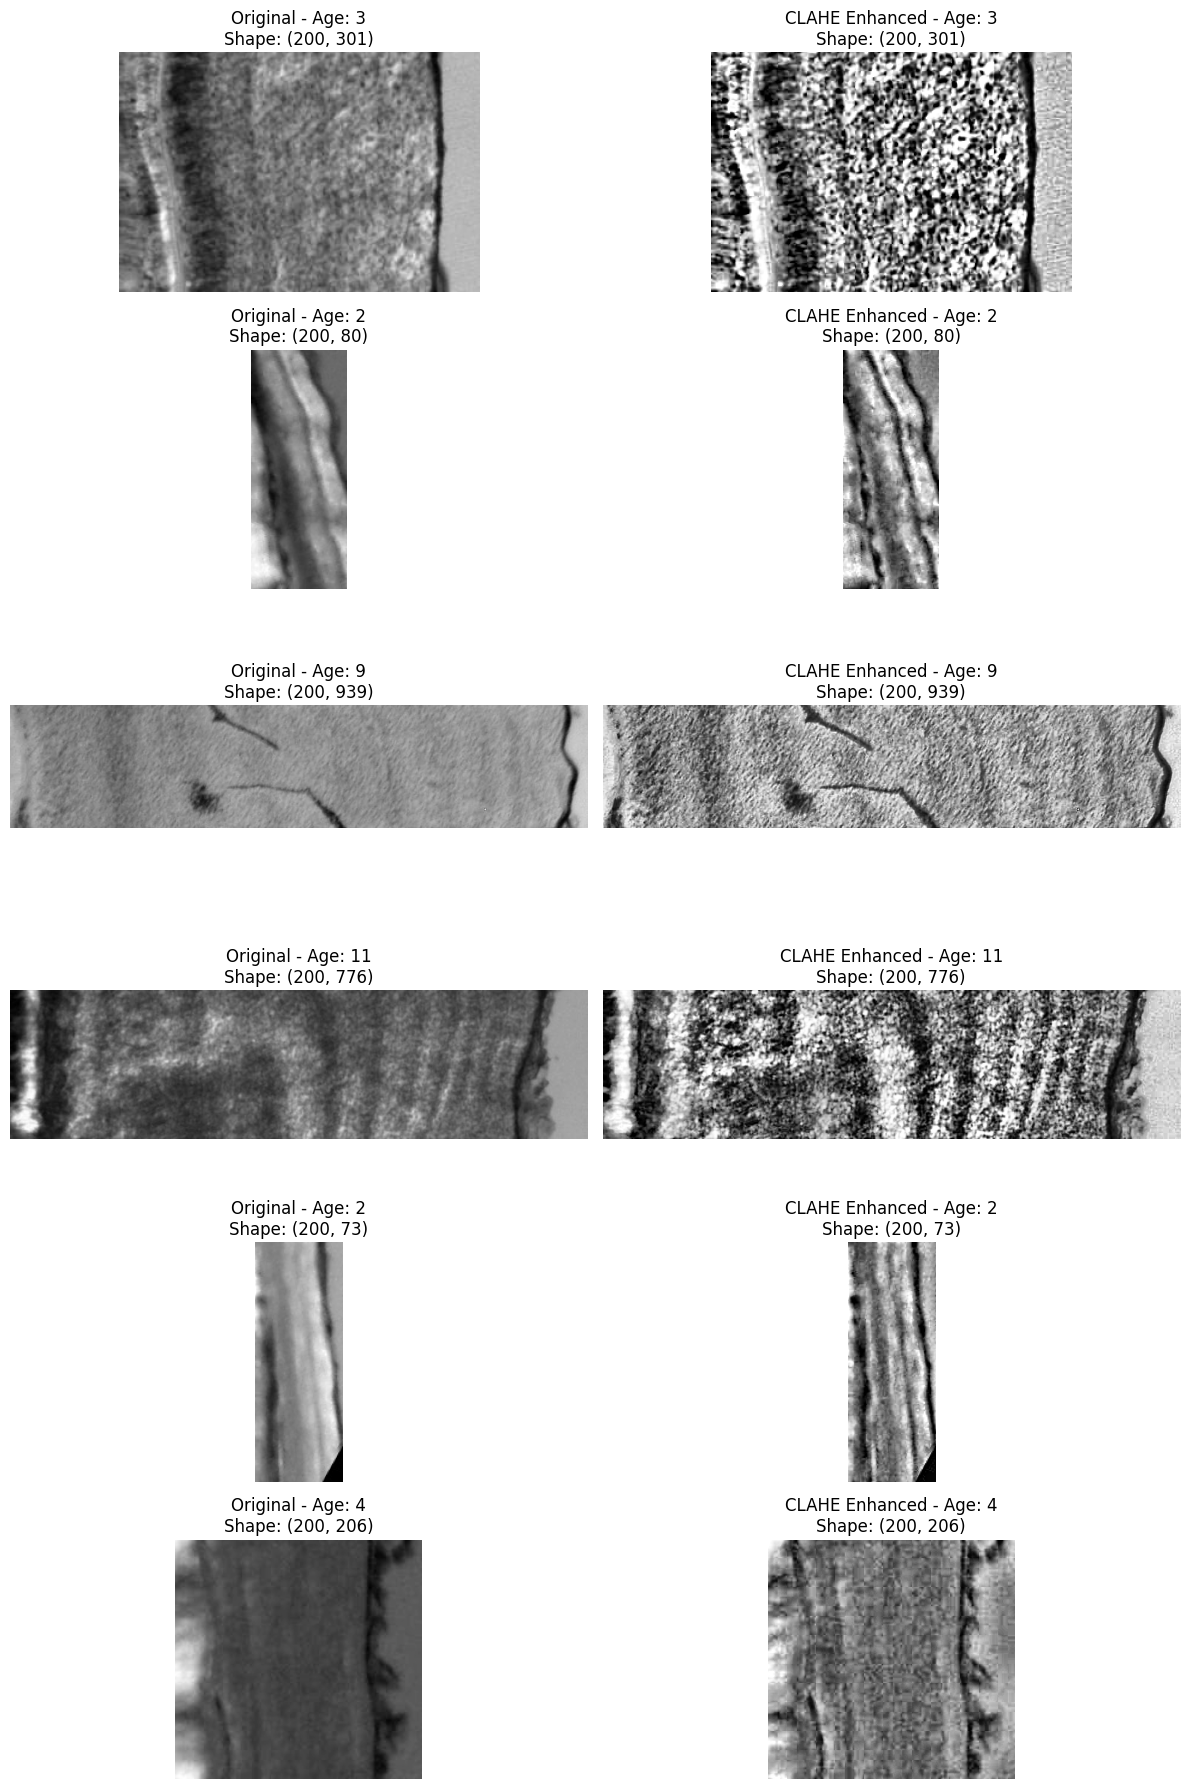


✓ Preprocessing complete! Check the visualization above.


In [11]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Configuration
CSV_PATH = "./training_data/labels.csv"      
IMAGES_DIR = "./training_data/images"    
IMAGE_COL = "image"
AGE_COL = "age"

# Load the CSV
df = pd.read_csv(CSV_PATH)
print(f"Dataset size: {len(df)} images")
print(f"\nAge statistics:")
print(df[AGE_COL].describe())
print(f"\nSample rows:")
print(df.head())

# CLAHE preprocessing function
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Apply CLAHE to enhance contrast in the image"""
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Apply CLAHE
    #clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    #enhanced = clahe.apply(gray)

    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    blur = cv2.GaussianBlur(enhanced, (0,0), 2)
    sharpened = cv2.addWeighted(enhanced, 2.0, blur, -1.0, 0)
    
    return sharpened

# Load and preprocess a single image
def load_and_preprocess(image_path):
    """Load image and return both original and CLAHE-enhanced versions"""
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    enhanced = apply_clahe(image)
    return image, enhanced

# Visualize samples
def visualize_samples(df, num_samples=6):
    """Display original vs CLAHE-enhanced images"""
    # Select random samples
    sample_indices = np.random.choice(len(df), min(num_samples, len(df)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, sample_idx in enumerate(sample_indices):
        row = df.iloc[sample_idx]
        image_path = os.path.join(IMAGES_DIR, row[IMAGE_COL])
        age = row[AGE_COL]
        
        try:
            original, enhanced = load_and_preprocess(image_path)
            
            # Original image
            axes[idx, 0].imshow(original, cmap='gray')
            axes[idx, 0].set_title(f'Original - Age: {age}\nShape: {original.shape}')
            axes[idx, 0].axis('off')
            
            # CLAHE enhanced
            axes[idx, 1].imshow(enhanced, cmap='gray')
            axes[idx, 1].set_title(f'CLAHE Enhanced - Age: {age}\nShape: {enhanced.shape}')
            axes[idx, 1].axis('off')
            
        except Exception as e:
            print(f"Error loading {image_path}: {e}")
            axes[idx, 0].text(0.5, 0.5, f'Error: {str(e)}', 
                            ha='center', va='center')
            axes[idx, 0].axis('off')
            axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('clahe_comparison.png', dpi=150, bbox_inches='tight')
    print("\nComparison saved to 'clahe_comparison.png'")
    plt.show()

# Check image dimensions to understand width variance
def analyze_dimensions(df, num_samples=50):
    """Analyze image dimensions in the dataset"""
    heights = []
    widths = []
    
    sample_size = min(num_samples, len(df))
    sample_indices = np.random.choice(len(df), sample_size, replace=False)
    
    for idx in sample_indices:
        row = df.iloc[idx]
        image_path = os.path.join(IMAGES_DIR, row[IMAGE_COL])
        try:
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                h, w = img.shape
                heights.append(h)
                widths.append(w)
        except Exception as e:
            print(f"Error reading {image_path}: {e}")
    
    if heights:
        print(f"\n=== Image Dimension Analysis (n={len(heights)}) ===")
        print(f"Height - Mean: {np.mean(heights):.1f}, Std: {np.std(heights):.1f}, Range: [{min(heights)}, {max(heights)}]")
        print(f"Width  - Mean: {np.mean(widths):.1f}, Std: {np.std(widths):.1f}, Range: [{min(widths)}, {max(widths)}]")
        print(f"Suggested padding width: {max(widths)}")
    
    return heights, widths

# Run the analysis and visualization
print("\n" + "="*50)
print("ANALYZING IMAGE DIMENSIONS")
print("="*50)
heights, widths = analyze_dimensions(df)

print("\n" + "="*50)
print("VISUALIZING ORIGINAL vs CLAHE")
print("="*50)
visualize_samples(df, num_samples=6)

print("\n✓ Preprocessing complete! Check the visualization above.")

In [ ]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import KFold
from tqdm import tqdm

# Configuration
CSV_PATH = "./training_data/labels.csv"      
IMAGES_DIR = "./training_data/images"    
IMAGE_COL = "image"
AGE_COL = "age"

TARGET_HEIGHT = 200
TARGET_WIDTH = 400  

BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE_BACKBONE = 1e-5
LEARNING_RATE_HEAD = 1e-3
K_FOLDS = 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
df = pd.read_csv(CSV_PATH)
print(f"Dataset size: {len(df)} images")
print(f"Age range: [{df[AGE_COL].min()}, {df[AGE_COL].max()}]")


Using device: cuda
Dataset size: 426 images
Age range: [1, 46]


In [13]:
def apply_preprocessing(image):
    """
    Apply CLAHE enhancement and sharpening to improve poor quality images
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Apply CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Sharpen the image
    blur = cv2.GaussianBlur(enhanced, (0, 0), 2)
    sharpened = cv2.addWeighted(enhanced, 2.0, blur, -1.0, 0)
    
    return sharpened


def resize_with_padding(image, target_height=TARGET_HEIGHT, target_width=TARGET_WIDTH):
    """
    Resize height and pad width to target dimensions
    """
    h, w = image.shape
    
    # Resize height to target
    if h != target_height:
        aspect_ratio = w / h
        new_width = int(target_height * aspect_ratio)
        image = cv2.resize(image, (new_width, target_height), interpolation=cv2.INTER_LINEAR)
        w = new_width
    
    # Pad width to target
    if w < target_width:
        pad_left = (target_width - w) // 2
        pad_right = target_width - w - pad_left
        image = cv2.copyMakeBorder(image, 0, 0, pad_left, pad_right, 
                                    cv2.BORDER_CONSTANT, value=0)
    elif w > target_width:
        # Center crop if wider than target
        start = (w - target_width) // 2
        image = image[:, start:start + target_width]
    
    return image

In [14]:
class SealToothDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform=None, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform
        self.augment = augment
        
        # Normalize age values for better training
        self.age_mean = dataframe[AGE_COL].mean()
        self.age_std = dataframe[AGE_COL].std()
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.images_dir, row[IMAGE_COL])
        age = row[AGE_COL]
        
        # Load and preprocess
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        
        # Apply CLAHE and sharpening
        image = apply_preprocessing(image)
        
        # Resize and pad
        image = resize_with_padding(image)
        
        # Convert to 3-channel for ResNet (expects RGB)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        # Convert to PIL Image for transforms
        from PIL import Image
        image = Image.fromarray(image)
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Normalize age
        age_normalized = (age - self.age_mean) / self.age_std
        
        return image, torch.tensor(age_normalized, dtype=torch.float32)

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
def create_model():
    """Create ResNet18 with regression head"""
    model = models.resnet18(pretrained=True)
    
    # Replace final FC layer with regression head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 1)
    )
    
    return model

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    
    for images, ages in tqdm(train_loader, desc="Training", leave=False):
        images, ages = images.to(device), ages.to(device)
        
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, ages)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

In [14]:
def validate(model, val_loader, criterion, device, age_mean, age_std):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, ages in tqdm(val_loader, desc="Validating", leave=False):
            images, ages = images.to(device), ages.to(device)
            
            outputs = model(images).squeeze()
            loss = criterion(outputs, ages)
            
            running_loss += loss.item() * images.size(0)
            
            # Denormalize predictions for MAE calculation
            preds_denorm = outputs.cpu().numpy() * age_std + age_mean
            targets_denorm = ages.cpu().numpy() * age_std + age_mean
            
            all_preds.extend(preds_denorm)
            all_targets.extend(targets_denorm)
    
    epoch_loss = running_loss / len(val_loader.dataset)
    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_targets)))
    
    return epoch_loss, mae

In [ ]:
full_dataset = SealToothDataset(df, IMAGES_DIR, transform=None)

# Initialize K-Fold
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_results = []
fold_models = []

print(f"\n{'='*60}")
print(f"Starting {K_FOLDS}-Fold Cross Validation")
print(f"{'='*60}\n")

for fold, (train_idx, val_idx) in enumerate(kfold.split(df)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*60}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
    
    # Create datasets for this fold
    train_dataset = SealToothDataset(
        df.iloc[train_idx], 
        IMAGES_DIR, 
        transform=train_transform
    )
    val_dataset = SealToothDataset(
        df.iloc[val_idx], 
        IMAGES_DIR, 
        transform=val_transform
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                             shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=0)
    
    # Create model
    model = create_model().to(device)
    
    # Loss function
    criterion = nn.MSELoss()
    
    # Optimizer with discriminative learning rates
    optimizer = optim.Adam([
        {'params': model.fc.parameters(), 'lr': LEARNING_RATE_HEAD},
        {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 
         'lr': LEARNING_RATE_BACKBONE}
    ])
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    # Early stopping
    best_val_mae = float('inf')
    patience = 10
    patience_counter = 0
    
    # Training loop
    train_losses = []
    val_losses = []
    val_maes = []
    
    for epoch in range(NUM_EPOCHS):
        # Train
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_mae = validate(
            model, val_loader, criterion, device, 
            train_dataset.age_mean, train_dataset.age_std
        )
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_maes.append(val_mae)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - "
              f"Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, "
              f"Val MAE: {val_mae:.2f} years")
        
        # Early stopping check
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            patience_counter = 0
            # Save best model for this fold
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # Store results
    fold_results.append({
        'fold': fold + 1,
        'best_val_mae': best_val_mae,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_maes': val_maes
    })
    fold_models.append(model)
    
    print(f"\nFold {fold + 1} Best Val MAE: {best_val_mae:.2f} years")


Starting 5-Fold Cross Validation


FOLD 1/5
Train samples: 340, Val samples: 86


Epoch 1/50 - Train Loss: 1.0474, Val Loss: 0.8695, Val MAE: 4.44 years


Epoch 2/50 - Train Loss: 1.0259, Val Loss: 0.6305, Val MAE: 3.54 years


Epoch 3/50 - Train Loss: 0.8361, Val Loss: 0.7820, Val MAE: 3.81 years


Epoch 4/50 - Train Loss: 0.7923, Val Loss: 0.5870, Val MAE: 3.31 years


...

Epoch 46/50 - Train Loss: 0.3306, Val Loss: 0.2069, Val MAE: 1.97 years


Epoch 47/50 - Train Loss: 0.3906, Val Loss: 0.2976, Val MAE: 2.37 years


Epoch 48/50 - Train Loss: 0.4080, Val Loss: 0.2913, Val MAE: 2.37 years


Epoch 49/50 - Train Loss: 0.4115, Val Loss: 0.2949, Val MAE: 2.37 years


Epoch 50/50 - Train Loss: 0.3818, Val Loss: 0.2617, Val MAE: 2.14 years
Early stopping triggered at epoch 50

Fold 5 Best Val MAE: 1.91 years



K-FOLD CROSS VALIDATION RESULTS

Fold 1: 3.29 years
Fold 2: 2.34 years
Fold 3: 2.70 years
Fold 4: 2.39 years
Fold 5: 1.91 years

Average MAE: 2.53 ± 0.46 years

Training curves saved to 'kfold_training_curves.png'


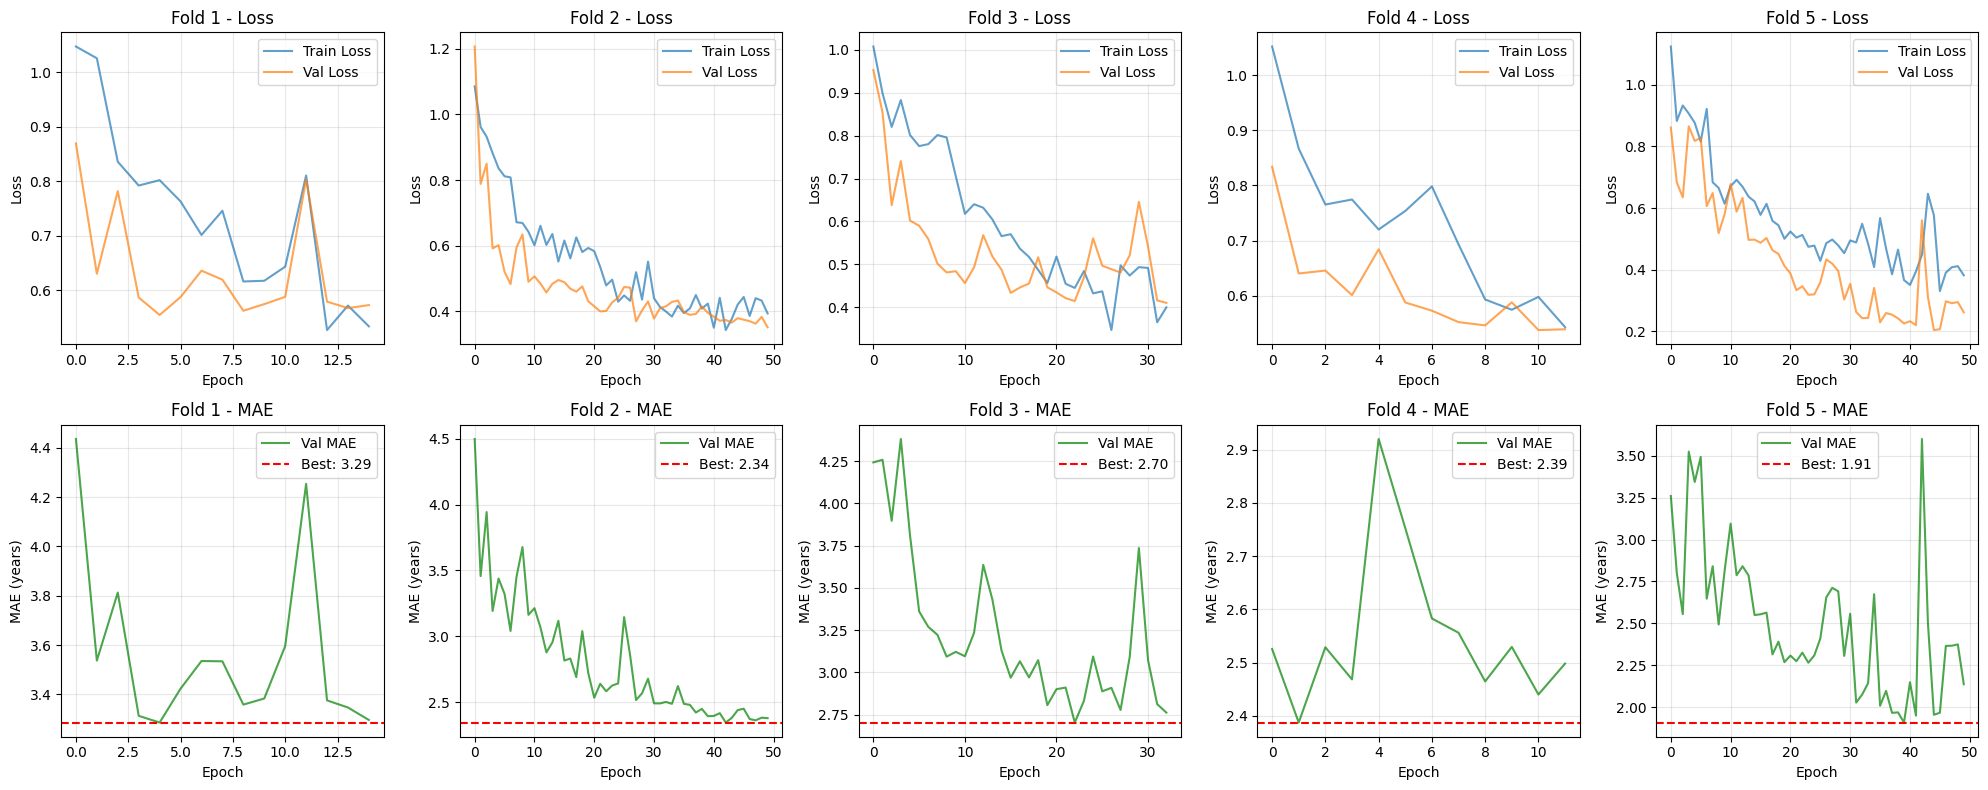


Best model (Fold 5) saved to 'best_seal_tooth_model.pth'


In [18]:
print(f"\n{'='*60}")
print("K-FOLD CROSS VALIDATION RESULTS")
print(f"{'='*60}\n")

fold_maes = [result['best_val_mae'] for result in fold_results]
mean_mae = np.mean(fold_maes)
std_mae = np.std(fold_maes)

for i, mae in enumerate(fold_maes):
    print(f"Fold {i+1}: {mae:.2f} years")

print(f"\n{'='*60}")
print(f"Average MAE: {mean_mae:.2f} ± {std_mae:.2f} years")
print(f"{'='*60}\n")

# Plot training curves for each fold
fig, axes = plt.subplots(2, K_FOLDS, figsize=(4*K_FOLDS, 8))

for i, result in enumerate(fold_results):
    # Loss curves
    axes[0, i].plot(result['train_losses'], label='Train Loss', alpha=0.7)
    axes[0, i].plot(result['val_losses'], label='Val Loss', alpha=0.7)
    axes[0, i].set_title(f"Fold {result['fold']} - Loss")
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # MAE curves
    axes[1, i].plot(result['val_maes'], label='Val MAE', color='green', alpha=0.7)
    axes[1, i].axhline(y=result['best_val_mae'], color='r', 
                       linestyle='--', label=f"Best: {result['best_val_mae']:.2f}")
    axes[1, i].set_title(f"Fold {result['fold']} - MAE")
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('MAE (years)')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kfold_training_curves.png', dpi=150, bbox_inches='tight')
print("Training curves saved to 'kfold_training_curves.png'")
plt.show()

# Save the best model (lowest MAE across all folds)
best_fold_idx = np.argmin(fold_maes)
best_model = fold_models[best_fold_idx]
torch.save(best_model.state_dict(), 'best_seal_tooth_model.pth')
print(f"\nBest model (Fold {best_fold_idx + 1}) saved to 'best_seal_tooth_model.pth'")

In [ ]:
import random

def predict_on_images(model, dataset, num_samples=12, device='cuda'):
    """
    Visualize model predictions on random samples
    """
    model.eval()
    
    # Select random samples
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    predictions = []
    actuals = []
    errors = []
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(indices):
            # Get image and actual age
            image_tensor, age_normalized = dataset[sample_idx]
            
            # Denormalize actual age
            actual_age = age_normalized.item() * dataset.age_std + dataset.age_mean
            
            # Get image path for display
            row = dataset.df.iloc[sample_idx]
            image_path = os.path.join(dataset.images_dir, row[IMAGE_COL])
            
            # Load original image for visualization (before preprocessing)
            original_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
            # Make prediction
            image_tensor = image_tensor.unsqueeze(0).to(device)
            pred_normalized = model(image_tensor).squeeze().cpu().item()
            
            # Denormalize prediction
            pred_age = pred_normalized * dataset.age_std + dataset.age_mean
            
            # Calculate error
            error = abs(pred_age - actual_age)
            
            predictions.append(pred_age)
            actuals.append(actual_age)
            errors.append(error)
            
            # Display
            axes[idx].imshow(original_img, cmap='gray')
            axes[idx].set_title(
                f'Actual: {actual_age:.1f} years\n'
                f'Predicted: {pred_age:.1f} years\n'
                f'Error: {error:.2f} years',
                fontsize=10,
                color='green' if error < 2 else 'orange' if error < 4 else 'red'
            )
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('prediction_samples.png', dpi=150, bbox_inches='tight')
    print("Prediction samples saved to 'prediction_samples.png'")
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print("PREDICTION STATISTICS ON SAMPLES")
    print(f"{'='*60}")
    print(f"Mean Absolute Error: {np.mean(errors):.2f} years")
    print(f"Max Error: {np.max(errors):.2f} years")
    print(f"Min Error: {np.min(errors):.2f} years")
    print(f"Std Error: {np.std(errors):.2f} years")
    
    return predictions, actuals, errors


def evaluate_full_dataset(model, dataset, device='cuda', batch_size=16):
    """
    Evaluate model on entire dataset and create scatter plot
    """
    model.eval()
    
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for images, ages_normalized in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            
            # Predict
            preds_normalized = model(images).squeeze().cpu().numpy()
            
            # Denormalize
            preds = preds_normalized * dataset.age_std + dataset.age_mean
            actuals = ages_normalized.numpy() * dataset.age_std + dataset.age_mean
            
            all_predictions.extend(preds)
            all_actuals.extend(actuals)
    
    all_predictions = np.array(all_predictions)
    all_actuals = np.array(all_actuals)
    errors = np.abs(all_predictions - all_actuals)
    
    # Create scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Scatter plot
    axes[0].scatter(all_actuals, all_predictions, alpha=0.5, s=50)
    axes[0].plot([all_actuals.min(), all_actuals.max()], 
                 [all_actuals.min(), all_actuals.max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Age (years)', fontsize=12)
    axes[0].set_ylabel('Predicted Age (years)', fontsize=12)
    axes[0].set_title(f'Predictions vs Actual\nMAE: {np.mean(errors):.2f} years', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Error distribution
    axes[1].hist(errors, bins=30, alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(errors), color='r', linestyle='--', 
                    linewidth=2, label=f'Mean: {np.mean(errors):.2f}')
    axes[1].axvline(np.median(errors), color='g', linestyle='--', 
                    linewidth=2, label=f'Median: {np.median(errors):.2f}')
    axes[1].set_xlabel('Absolute Error (years)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Error Distribution', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('prediction_analysis.png', dpi=150, bbox_inches='tight')
    print("Analysis saved to 'prediction_analysis.png'")
    plt.show()
    
    # Print detailed statistics
    print(f"\n{'='*60}")
    print("FULL DATASET EVALUATION")
    print(f"{'='*60}")
    print(f"Total samples: {len(all_actuals)}")
    print(f"Mean Absolute Error: {np.mean(errors):.2f} years")
    print(f"Median Absolute Error: {np.median(errors):.2f} years")
    print(f"Root Mean Squared Error: {np.sqrt(np.mean(errors**2)):.2f} years")
    print(f"Max Error: {np.max(errors):.2f} years")
    print(f"Percentage within ±1 year: {100 * np.mean(errors <= 1):.1f}%")
    print(f"Percentage within ±2 years: {100 * np.mean(errors <= 2):.1f}%")
    print(f"Percentage within ±3 years: {100 * np.mean(errors <= 3):.1f}%")
    print(f"{'='*60}\n")
    
    return all_predictions, all_actuals, errors


def show_best_worst_predictions(model, dataset, device='cuda', num_samples=6):
    """
    Show the best and worst predictions
    """
    model.eval()
    
    # Get all predictions
    all_preds = []
    all_actuals = []
    all_indices = []
    
    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Computing predictions"):
            image_tensor, age_normalized = dataset[idx]
            actual_age = age_normalized.item() * dataset.age_std + dataset.age_mean
            
            image_tensor = image_tensor.unsqueeze(0).to(device)
            pred_normalized = model(image_tensor).squeeze().cpu().item()
            pred_age = pred_normalized * dataset.age_std + dataset.age_mean
            
            all_preds.append(pred_age)
            all_actuals.append(actual_age)
            all_indices.append(idx)
    
    # Calculate errors
    errors = np.abs(np.array(all_preds) - np.array(all_actuals))
    
    # Get best and worst indices
    sorted_indices = np.argsort(errors)
    best_indices = sorted_indices[:num_samples]
    worst_indices = sorted_indices[-num_samples:]
    
    # Visualize
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    
    # Best predictions
    for i, idx in enumerate(best_indices):
        row = dataset.df.iloc[idx]
        image_path = os.path.join(dataset.images_dir, row[IMAGE_COL])
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(
            f'Act: {all_actuals[idx]:.1f}\n'
            f'Pred: {all_preds[idx]:.1f}\n'
            f'Err: {errors[idx]:.2f}',
            fontsize=10, color='green'
        )
        axes[0, i].axis('off')
    
    axes[0, 0].set_ylabel('BEST', fontsize=14, fontweight='bold')
    
    # Worst predictions
    for i, idx in enumerate(worst_indices):
        row = dataset.df.iloc[idx]
        image_path = os.path.join(dataset.images_dir, row[IMAGE_COL])
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(
            f'Act: {all_actuals[idx]:.1f}\n'
            f'Pred: {all_preds[idx]:.1f}\n'
            f'Err: {errors[idx]:.2f}',
            fontsize=10, color='red'
        )
        axes[1, i].axis('off')
    
    axes[1, 0].set_ylabel('WORST', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('best_worst_predictions.png', dpi=150, bbox_inches='tight')
    print("Best/worst predictions saved to 'best_worst_predictions.png'")
    plt.show()




Loaded best model from 'best_seal_tooth_model.pth'
Evaluation dataset size: 426 images

Visualizing random prediction samples...
Prediction samples saved to 'prediction_samples.png'


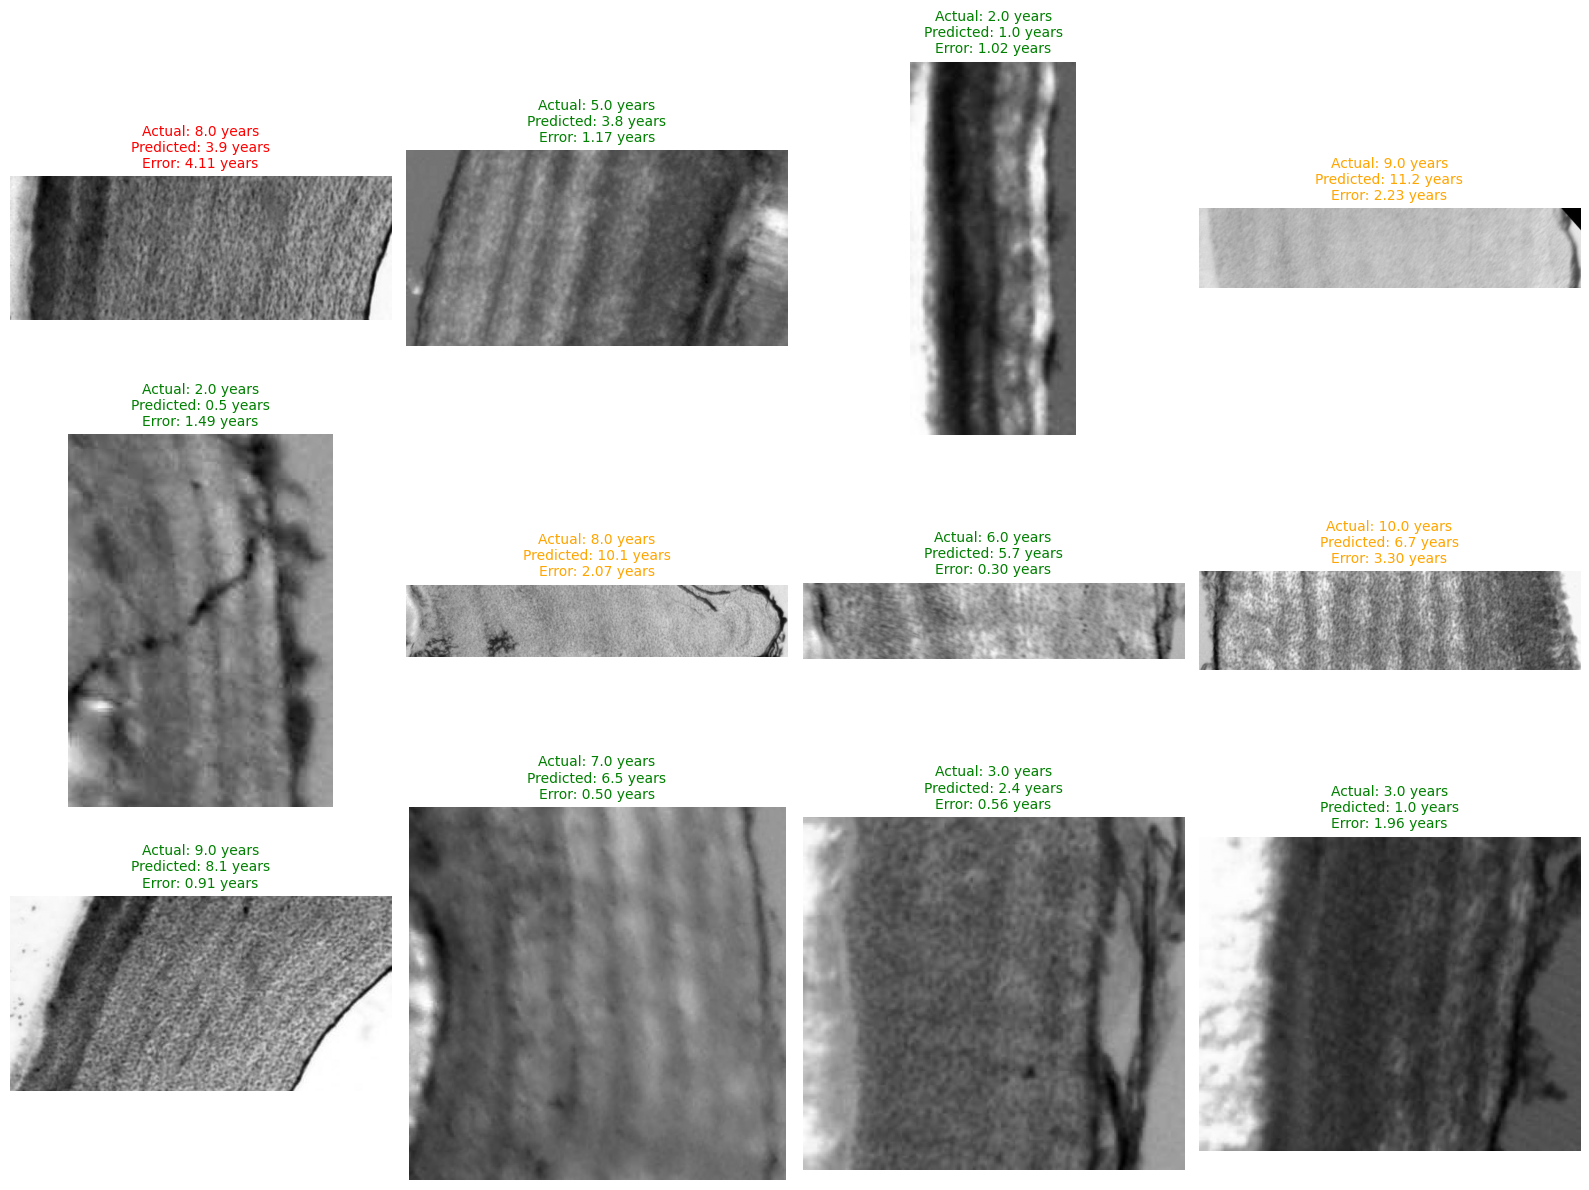


PREDICTION STATISTICS ON SAMPLES
Mean Absolute Error: 1.63 years
Max Error: 4.11 years
Min Error: 0.30 years
Std Error: 1.12 years

Evaluating on full validation set...


Evaluating: 100%|██████████| 27/27 [00:05<00:00,  4.99it/s]


Analysis saved to 'prediction_analysis.png'


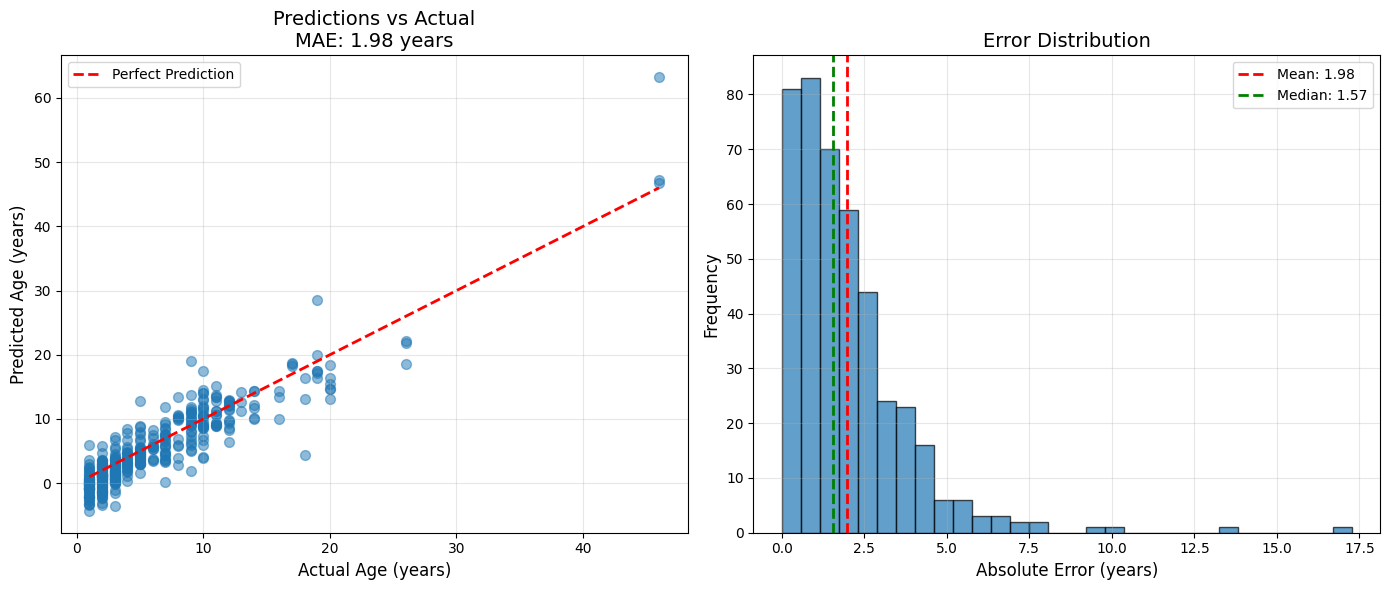


FULL DATASET EVALUATION
Total samples: 426
Mean Absolute Error: 1.98 years
Median Absolute Error: 1.57 years
Root Mean Squared Error: 2.69 years
Max Error: 17.26 years
Percentage within ±1 year: 33.3%
Percentage within ±2 years: 62.7%
Percentage within ±3 years: 79.8%


Showing best and worst predictions...


Computing predictions: 100%|██████████| 426/426 [00:03<00:00, 116.00it/s]


Best/worst predictions saved to 'best_worst_predictions.png'


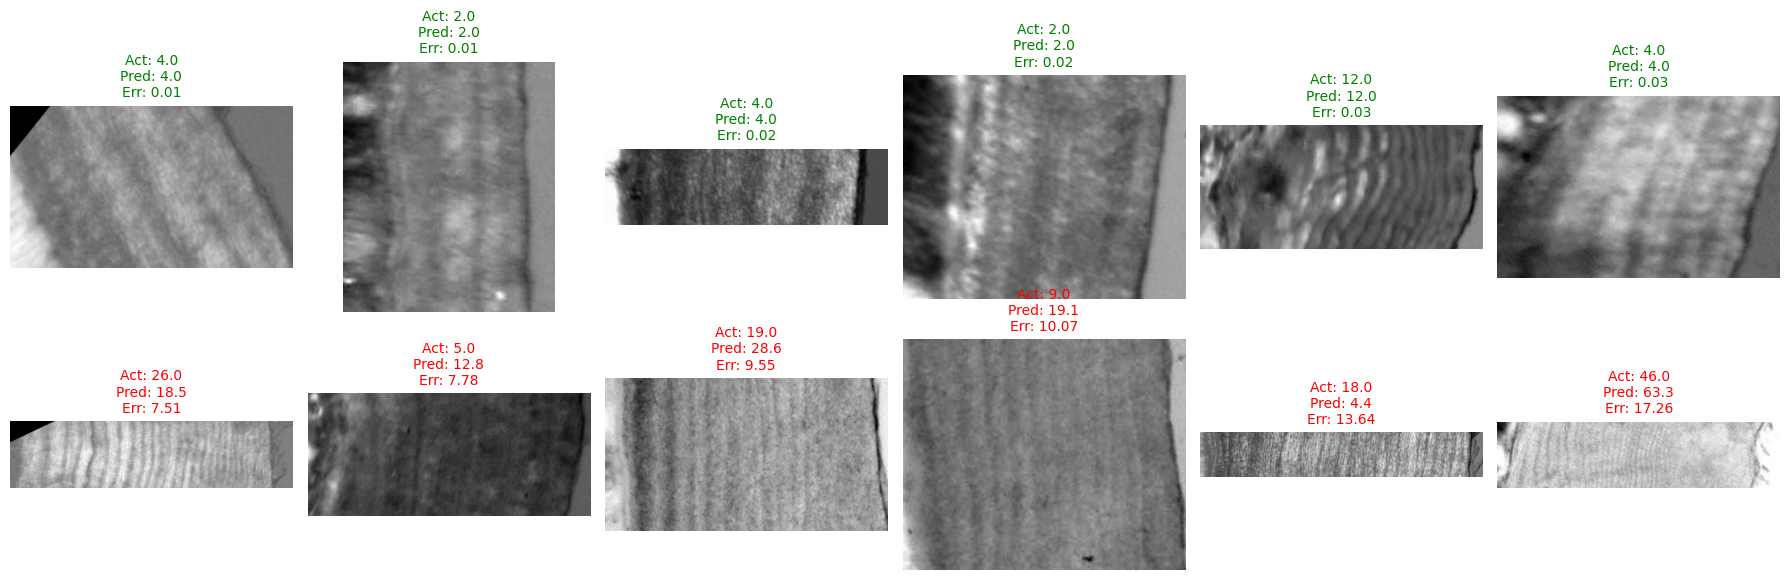

In [ ]:
# Create a fresh model
best_model = create_model().to(device)

# Load the saved weights
best_model.load_state_dict(torch.load('best_seal_tooth_model.pth'))
best_model.eval()

print(f"Loaded best model from 'best_seal_tooth_model.pth'")

eval_dataset = SealToothDataset(
    df,  
    IMAGES_DIR, 
    transform=val_transform
)

print(f"Evaluation dataset size: {len(eval_dataset)} images")
print("\nVisualizing random prediction samples...")
predictions, actuals, errors = predict_on_images(best_model, eval_dataset, num_samples=12, device=device)

print("\nEvaluating on full validation set...")
all_preds, all_actuals, all_errors = evaluate_full_dataset(best_model, eval_dataset, device=device)

print("\nShowing best and worst predictions...")
show_best_worst_predictions(best_model, eval_dataset, device=device, num_samples=6)

Computing predictions: 100%|██████████| 426/426 [00:04<00:00, 105.71it/s]


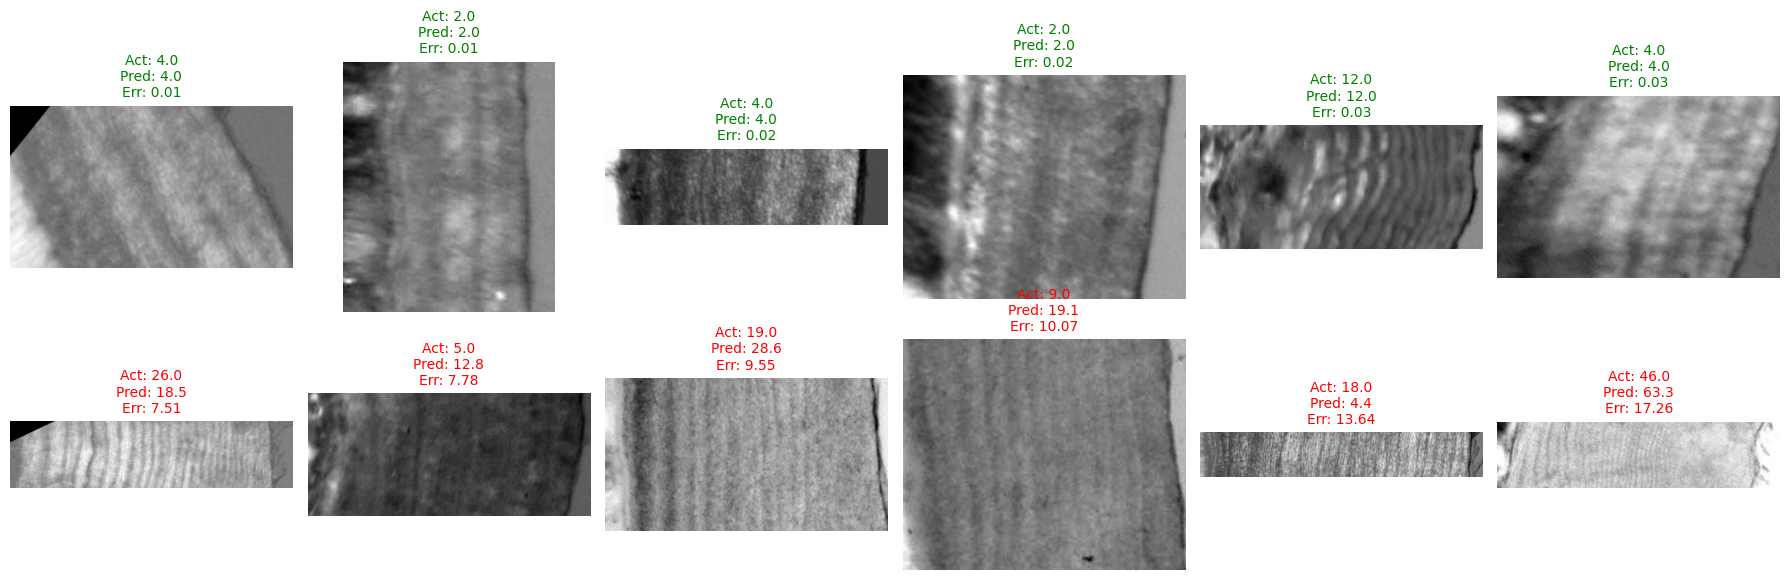


Overall MAE: 1.98 years


In [22]:
def show_best_worst_predictions(model, dataset, device='cuda', num_samples=6):
    """
    Show the best and worst predictions
    """
    model.eval()
    
    # Get all predictions
    all_preds = []
    all_actuals = []
    all_indices = []
    
    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Computing predictions"):
            image_tensor, age_normalized = dataset[idx]
            actual_age = age_normalized.item() * dataset.age_std + dataset.age_mean
            
            image_tensor = image_tensor.unsqueeze(0).to(device)
            pred_normalized = model(image_tensor).squeeze().cpu().item()
            pred_age = pred_normalized * dataset.age_std + dataset.age_mean
            
            all_preds.append(pred_age)
            all_actuals.append(actual_age)
            all_indices.append(idx)
    
    # Calculate errors
    errors = np.abs(np.array(all_preds) - np.array(all_actuals))
    
    # Get best and worst indices
    sorted_indices = np.argsort(errors)
    best_indices = sorted_indices[:num_samples]
    worst_indices = sorted_indices[-num_samples:]
    
    # Visualize
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    
    # Best predictions
    for i, idx in enumerate(best_indices):
        row = dataset.df.iloc[idx]
        image_path = os.path.join(dataset.images_dir, row[IMAGE_COL])
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(
            f'Act: {all_actuals[idx]:.1f}\n'
            f'Pred: {all_preds[idx]:.1f}\n'
            f'Err: {errors[idx]:.2f}',
            fontsize=10, color='green'
        )
        axes[0, i].axis('off')
    
    axes[0, 0].set_ylabel('BEST', fontsize=14, fontweight='bold')
    
    # Worst predictions
    for i, idx in enumerate(worst_indices):
        row = dataset.df.iloc[idx]
        image_path = os.path.join(dataset.images_dir, row[IMAGE_COL])
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(
            f'Act: {all_actuals[idx]:.1f}\n'
            f'Pred: {all_preds[idx]:.1f}\n'
            f'Err: {errors[idx]:.2f}',
            fontsize=10, color='red'
        )
        axes[1, i].axis('off')
    
    axes[1, 0].set_ylabel('WORST', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('best_worst_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nOverall MAE: {np.mean(errors):.2f} years")


# Run it
show_best_worst_predictions(best_model, eval_dataset, device=device, num_samples=6)